<a href="https://colab.research.google.com/github/bandiamithsreenivasareddy/AirTouch-Real-time-Gesture-Based-Cursor-Control/blob/main/NLP_3_T5_remediation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Notebook 3: T5 Remediation Model — Toxic → Non-Toxic Rewriting

CATPIC — Context-Aware Framework for Political Toxicity

This notebook fine-tunes T5-small to rewrite toxic text into non-toxic versions while preserving meaning.

Training data: Filtered ParaNMT-Detox (toxic → non-toxic parallel sentence pairs)

Run Notebook 1 first to generate processed data.

In [ ]:
# ============================================================
# Cell 1: Install & Imports
# ============================================================

!pip install -q transformers accelerate sentencepiece tqdm

import os
import pickle
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    T5ForConditionalGeneration,
    T5Tokenizer,
    get_linear_schedule_with_warmup
)
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


In [ ]:
# ============================================================
# Cell 1b: Google Drive Setup — mount to persist T5 model
# ============================================================

import shutil

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_BASE = '/content/drive/MyDrive/CATPIC_Project/'
    os.makedirs(DRIVE_BASE + 'models/', exist_ok=True)
    USE_DRIVE = True
    print(f'Google Drive mounted. T5 model will be saved to:\n {DRIVE_BASE}models/catpic_t5_detox_best/')

    # Restore detox_processed.pkl from Drive if missing locally
    drive_pkl = DRIVE_BASE + 'data/processed/detox_processed.pkl'
    local_pkl = 'data/processed/detox_processed.pkl'
    if not os.path.exists(local_pkl) and os.path.exists(drive_pkl):
        os.makedirs('data/processed/', exist_ok=True)
        shutil.copy(drive_pkl, local_pkl)
        print(' Restored detox_processed.pkl from Drive.')
except ImportError:
    USE_DRIVE = False
    print('Not running on Colab — Google Drive mounting skipped.')

Mounted at /content/drive
Google Drive mounted. T5 model will be saved to:
 /content/drive/MyDrive/CATPIC_Project/models/catpic_t5_detox_best/
 Restored detox_processed.pkl from Drive.


In [ ]:
# ============================================================
# Cell 2: Load processed detox data
# ============================================================

with open('data/processed/detox_processed.pkl', 'rb') as f:
    detox_data = pickle.load(f)

detox_train = detox_data['train']
detox_val = detox_data['val']
detox_test = detox_data['test']

print(f'Detox Train: {len(detox_train)}, Val: {len(detox_val)}, Test: {len(detox_test)}')
print(f'\nColumns: {detox_train.columns.tolist()}')
print(f'\nSample pair:')
print(f' TOXIC: {detox_train.iloc[0]["toxic_text"][:120]}')
print(f' CLEAN: {detox_train.iloc[0]["clean_text"][:120]}')

Detox Train: 51000, Val: 6030, Test: 2970

Columns: ['toxic_text', 'clean_text', 'similarity', 'toxic_score', 'clean_score']

Sample pair:
 TOXIC: all eight of you go to hell.
 CLEAN: Eight of you, off out of here.


In [ ]:
# ============================================================
# Cell 3: T5 Tokenizer & Dataset class
# ============================================================

MODEL_NAME = 't5-small'
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME, legacy=True)

SRC_MAX_LEN = 128
TGT_MAX_LEN = 128

class DetoxDataset(Dataset):
    def __init__(self, df, tokenizer, src_max_len=128, tgt_max_len=128):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.src_max_len = src_max_len
        self.tgt_max_len = tgt_max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Add task prefix for T5
        source_text = f"detoxify: {row['toxic_text']}"
        target_text = str(row['clean_text'])

        # Tokenize source
        source = self.tokenizer(
            source_text,
            max_length=self.src_max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # Tokenize target
        target = self.tokenizer(
            target_text,
            max_length=self.tgt_max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # Replace padding token id with -100 so it's ignored in loss
        labels = target['input_ids'].squeeze(0).clone()
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            'input_ids': source['input_ids'].squeeze(0),
            'attention_mask': source['attention_mask'].squeeze(0),
            'labels': labels,
            'decoder_attention_mask': target['attention_mask'].squeeze(0)
        }

# Create datasets
train_dataset = DetoxDataset(detox_train, tokenizer, SRC_MAX_LEN, TGT_MAX_LEN)
val_dataset = DetoxDataset(detox_val, tokenizer, SRC_MAX_LEN, TGT_MAX_LEN)
test_dataset = DetoxDataset(detox_test, tokenizer, SRC_MAX_LEN, TGT_MAX_LEN)

# Verify
sample = train_dataset[0]
print('Sample shapes:')
for k, v in sample.items():
    print(f' {k}: {v.shape}')

# Decode to verify
decoded_src = tokenizer.decode(sample['input_ids'], skip_special_tokens=True)
decoded_tgt = tokenizer.decode(sample['labels'][sample['labels'] != -100], skip_special_tokens=True)
print(f'\nDecoded source: {decoded_src[:100]}')
print(f'Decoded target: {decoded_tgt[:100]}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Sample shapes:
 input_ids: torch.Size([128])
 attention_mask: torch.Size([128])
 labels: torch.Size([128])
 decoder_attention_mask: torch.Size([128])

Decoded source: detoxify: all eight of you go to hell.
Decoded target: Eight of you, off out of here.


In [ ]:
# ============================================================
# Cell 4: Load T5 model and setup training
# ============================================================

model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'T5-small parameters: {total_params:,}')

# Training hyperparameters
BATCH_SIZE = 16
LEARNING_RATE = 3e-4
NUM_EPOCHS = 4
ACCUMULATION_STEPS = 2  # Effective batch size = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
total_steps = (len(train_loader) // ACCUMULATION_STEPS) * NUM_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

print(f'Batch size: {BATCH_SIZE} (effective: {BATCH_SIZE * ACCUMULATION_STEPS})')
print(f'Total steps: {total_steps}')
print(f'Train batches per epoch: {len(train_loader)}')

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

T5-small parameters: 60,506,624
Batch size: 16 (effective: 32)
Total steps: 6376
Train batches per epoch: 3188


In [ ]:
# ============================================================
# Cell 5: Training and Evaluation Functions
# ============================================================

def train_epoch(model, loader, optimizer, scheduler, accumulation_steps=2):
    model.train()
    total_loss = 0
    optimizer.zero_grad()
    num_batches = len(loader)

    for step, batch in enumerate(tqdm(loader, desc='Training', leave=False)):
        outputs = model(
            input_ids=batch['input_ids'].to(device),
            attention_mask=batch['attention_mask'].to(device),
            labels=batch['labels'].to(device),
            decoder_attention_mask=batch['decoder_attention_mask'].to(device)
        )

        loss = outputs.loss / accumulation_steps
        loss.backward()
        total_loss += outputs.loss.item()

        if (step + 1) % accumulation_steps == 0 or (step + 1) == num_batches:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

    return total_loss / num_batches


@torch.no_grad()
def evaluate_loss(model, loader):
    model.eval()
    total_loss = 0

    for batch in tqdm(loader, desc='Evaluating', leave=False):
        outputs = model(
            input_ids=batch['input_ids'].to(device),
            attention_mask=batch['attention_mask'].to(device),
            labels=batch['labels'].to(device),
            decoder_attention_mask=batch['decoder_attention_mask'].to(device)
        )
        total_loss += outputs.loss.item()

    return total_loss / len(loader)


def generate_detoxified(model, tokenizer, texts, max_length=128, num_beams=4):
    """Generate detoxified versions of input texts."""
    model.eval()
    results = []

    for text in texts:
        input_text = f"detoxify: {text}"
        inputs = tokenizer(
            input_text,
            max_length=128,
            padding=True,
            truncation=True,
            return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            outputs = model.generate(
                input_ids=inputs['input_ids'],
                attention_mask=inputs['attention_mask'],
                max_length=max_length,
                num_beams=num_beams,
                early_stopping=True,
                no_repeat_ngram_size=3
            )

        decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
        results.append(decoded)

    return results


print('Functions ready.')

Functions ready.


In [ ]:
# ============================================================
# Cell 6: Training Loop
# ============================================================

history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
patience = 2
patience_counter = 0

print('='*70)
print('Starting T5 Remediation Model Training')
print('='*70)

for epoch in range(NUM_EPOCHS):
    print(f'\nEpoch {epoch+1}/{NUM_EPOCHS}')
    print('-'*50)

    train_loss = train_epoch(model, train_loader, optimizer, scheduler, ACCUMULATION_STEPS)
    val_loss = evaluate_loss(model, val_loader)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    print(f' Train Loss: {train_loss:.4f}')
    print(f' Val Loss:   {val_loss:.4f}')

    # Sample generations every epoch
    sample_texts = [
        "Those idiots in congress are destroying everything.",
        "Shut up you stupid moron, your political opinions are garbage.",
        "I hate all those corrupt politicians, they should be punished."
    ]
    detoxified = generate_detoxified(model, tokenizer, sample_texts)
    print('\n Sample generations:')
    for orig, detox in zip(sample_texts, detoxified):
        print(f'   IN:  {orig}')
        print(f'   OUT: {detox}')
        print()

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        model.save_pretrained('models/catpic_t5_detox_best')
        tokenizer.save_pretrained('models/catpic_t5_detox_best')
        print(f' >>> New best model saved! (val_loss: {val_loss:.4f})')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f' Early stopping at epoch {epoch+1}')
            break

print('\n' + '='*70)
print('T5 Remediation Training Complete!')
print('='*70)

Starting T5 Remediation Model Training

Epoch 1/4
--------------------------------------------------


Training:   0%|          | 0/3188 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/377 [00:00<?, ?it/s]

 Train Loss: 2.1311
 Val Loss:   1.8530

 Sample generations:
   IN:  Those idiots in congress are destroying everything.
   OUT: the idiots in Congress are destroying everything.

   IN:  Shut up you stupid moron, your political opinions are garbage.
   OUT: keep quiet, your political opinions are bad.

   IN:  I hate all those corrupt politicians, they should be punished.
   OUT: I hate all those corrupt politicians, they should be punished.



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Training:   0%|          | 0/3188 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/377 [00:00<?, ?it/s]

 Train Loss: 1.7485
 Val Loss:   1.7822

 Sample generations:
   IN:  Those idiots in congress are destroying everything.
   OUT: they're destroying everything in Congress.

   IN:  Shut up you stupid moron, your political opinions are garbage.
   OUT: keep quiet, your political opinion is a waste.

   IN:  I hate all those corrupt politicians, they should be punished.
   OUT: I hate all those corrupt politicians, they should be punished.



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 >>> New best model saved! (val_loss: 1.7822)

T5 Remediation Training Complete!


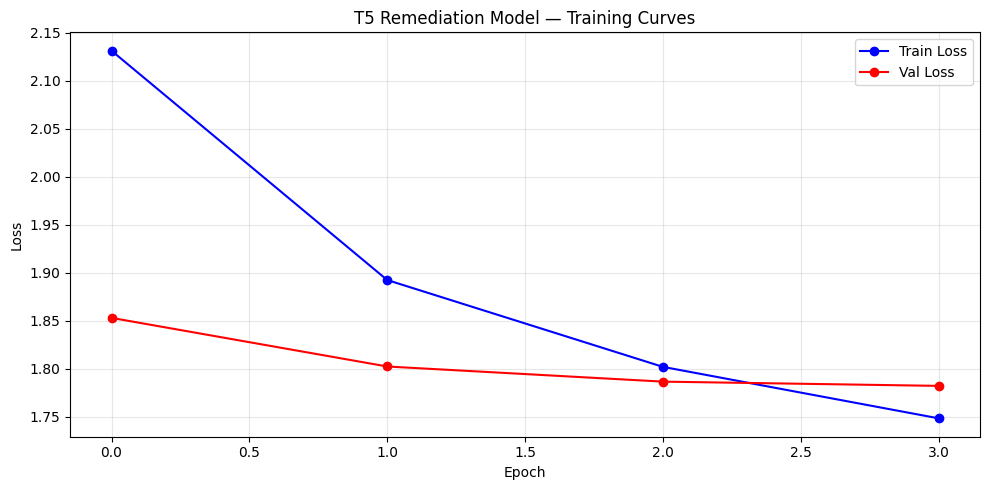

In [ ]:
# ============================================================
# Cell 7: Training curves
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history['train_loss'], 'b-o', label='Train Loss')
ax.plot(history['val_loss'], 'r-o', label='Val Loss')
ax.set_title('T5 Remediation Model — Training Curves')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('models/training_curves_t5.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# Cell 8: Test Set Evaluation (Quantitative)
# ============================================================

!pip install -q nltk rouge-score
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

# Load best model
model = T5ForConditionalGeneration.from_pretrained('models/catpic_t5_detox_best').to(device)
tokenizer = T5Tokenizer.from_pretrained('models/catpic_t5_detox_best', legacy=True)
print('Best model loaded.')

# Evaluate on test set subset (full set would take too long)
N_EVAL = 500
eval_df = detox_test.head(N_EVAL).reset_index(drop=True)

print(f'Evaluating on {N_EVAL} test samples...')
generated_texts = []

for i in tqdm(range(0, N_EVAL, 8), desc='Generating'):
    batch_texts = eval_df['toxic_text'].iloc[i:i+8].tolist()
    batch_generated = generate_detoxified(model, tokenizer, batch_texts, num_beams=4)
    generated_texts.extend(batch_generated)

eval_df['generated'] = generated_texts[:N_EVAL]
print(f'Generated {len(generated_texts)} detoxified texts.')

  Preparing metadata (setup.py) ... done


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Best model loaded.
Evaluating on 500 test samples...


Generating:   0%|          | 0/63 [00:00<?, ?it/s]

Generated 500 detoxified texts.


In [ ]:
# ============================================================
# Cell 9: Compute BLEU, ROUGE, and toxicity reduction metrics
# ============================================================

smoother = SmoothingFunction().method1
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

bleu_scores = []
rouge1_scores = []
rouge2_scores = []
rougel_scores = []

for idx, row in eval_df.iterrows():
    reference = str(row['clean_text'])
    hypothesis = str(row['generated'])

    # BLEU
    try:
        ref_tokens = reference.lower().split()
        hyp_tokens = hypothesis.lower().split()
        bleu = sentence_bleu([ref_tokens], hyp_tokens, smoothing_function=smoother)
        bleu_scores.append(bleu)
    except Exception:
        bleu_scores.append(0.0)

    # ROUGE
    try:
        rouge_result = scorer.score(reference, hypothesis)
        rouge1_scores.append(rouge_result['rouge1'].fmeasure)
        rouge2_scores.append(rouge_result['rouge2'].fmeasure)
        rougel_scores.append(rouge_result['rougeL'].fmeasure)
    except Exception:
        rouge1_scores.append(0.0)
        rouge2_scores.append(0.0)
        rougel_scores.append(0.0)

print('-'*60)
print('T5 REMEDIATION — TEST SET METRICS')
print('-'*60)
print(f'BLEU Score:   {np.mean(bleu_scores):.4f} (±{np.std(bleu_scores):.4f})')
print(f'ROUGE-1 F1:   {np.mean(rouge1_scores):.4f} (±{np.std(rouge1_scores):.4f})')
print(f'ROUGE-2 F1:   {np.mean(rouge2_scores):.4f} (±{np.std(rouge2_scores):.4f})')
print(f'ROUGE-L F1:   {np.mean(rougel_scores):.4f} (±{np.std(rougel_scores):.4f})')
print()

# Show some good examples
print('--- Sample Detoxification Results ---')
for i in range(min(10, len(eval_df))):
    row = eval_df.iloc[i]
    print(f'\n[{i+1}]')
    print(f' TOXIC:      {row["toxic_text"][:120]}')
    print(f' GENERATED:  {row["generated"][:120]}')
    print(f' REFERENCE:  {row["clean_text"][:120]}')

------------------------------------------------------------
T5 REMEDIATION — TEST SET METRICS
------------------------------------------------------------
BLEU Score:   0.2039 (±0.2203)
ROUGE-1 F1:   0.6095 (±0.1891)
ROUGE-2 F1:   0.3632 (±0.2590)
ROUGE-L F1:   0.5910 (±0.1975)

--- Sample Detoxification Results ---

[1]
 TOXIC:      Hey, we got a hit on our clown car.
 GENERATED:  hey, we got a hit on our car.
 REFERENCE:  hey, we found the clown car.

[2]
 TOXIC:      he grabbed me, punched me, punched me in the gut, and he slammed the door in my face.
 GENERATED:  He grabbed me, punched me in the gut, and slammed the door in my face.
 REFERENCE:  He grips me, swipes me, swats me one in the breadbasket and slams the door in me face.

[3]
 TOXIC:      you pissed on my face, buddy.
 GENERATED:  You pissed on my face, buddy.
 REFERENCE:  "Yeah, you do. You pissed on my face, friend."

[4]
 TOXIC:      let's close him up.
 GENERATED:  Let's close it up.
 REFERENCE:  Lock him up.

[5]
 T

In [ ]:
# ============================================================
# Cell 10: Save T5 evaluation results
# ============================================================

t5_results = {
    'bleu': np.mean(bleu_scores),
    'rouge1': np.mean(rouge1_scores),
    'rouge2': np.mean(rouge2_scores),
    'rougeL': np.mean(rougel_scores),
    'history': history,
    'eval_df': eval_df,
    'config': {
        'model': MODEL_NAME,
        'src_max_len': SRC_MAX_LEN,
        'tgt_max_len': TGT_MAX_LEN,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'num_epochs': NUM_EPOCHS
    }
}

with open('models/t5_remediation_results.pkl', 'wb') as f:
    pickle.dump(t5_results, f)

print('T5 results saved to models/t5_remediation_results.pkl')
print('T5 model saved to models/catpic_t5_detox_best/')
print('\n=== Notebook 3 Complete — Proceed to Notebook 4 ===')

T5 results saved to models/t5_remediation_results.pkl
T5 model saved to models/catpic_t5_detox_best/

=== Notebook 3 Complete — Proceed to Notebook 4 ===


In [ ]:
# ============================================================
# Cell 11: Backup T5 model + results to Google Drive
# ============================================================

if USE_DRIVE:
    print('Backing up T5 model to Google Drive...')

    # Save full T5 model directory to Drive
    t5_drive_dir = DRIVE_BASE + 'models/catpic_t5_detox_best/'
    os.makedirs(t5_drive_dir, exist_ok=True)
    for fname in os.listdir('models/catpic_t5_detox_best'):
        src = os.path.join('models/catpic_t5_detox_best', fname)
        dst = os.path.join(t5_drive_dir, fname)
        shutil.copy(src, dst)
        print(f' {fname} -> Drive')

    # Results pickle
    shutil.copy('models/t5_remediation_results.pkl',
                DRIVE_BASE + 'models/t5_remediation_results.pkl')
    print(' t5_remediation_results.pkl -> Drive')

    # Training curve plot
    if os.path.exists('models/training_curves_t5.png'):
        shutil.copy('models/training_curves_t5.png',
                    DRIVE_BASE + 'models/training_curves_t5.png')
        print(' training_curves_t5.png -> Drive')

    print(f'\nT5 model backed up to:\n {DRIVE_BASE}models/catpic_t5_detox_best/')
else:
    print('Drive not mounted — skipping Drive backup.')
    print('Run the Google Drive Setup cell (Cell 1b) first if you want Drive backup.')

Backing up T5 model to Google Drive...
 model.safetensors -> Drive
 tokenizer.json -> Drive
 config.json -> Drive
 tokenizer_config.json -> Drive
 generation_config.json -> Drive
 t5_remediation_results.pkl -> Drive
 training_curves_t5.png -> Drive

T5 model backed up to:
 /content/drive/MyDrive/CATPIC_Project/models/catpic_t5_detox_best/
